# **Student Performance Indicator**

### **Life cycle of Machine learning Project**



* Understanding the Problem Statement
* Data Collection
* Data Checks to perform
* Exploratory data analysis
* Data Pre-Processing
* Model Training
* Choose best model  



### **1) Problem statement**

This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

### **2) Data Collection**

* Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
* The data consists of 8 column and 1000 rows.

#### **2.1 Import Data and Required Packages**
Importing **Pandas, Numpy, Matplotlib, Seaborn** and **Warings Library**.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

**Import the CSV Data as Pandas DataFrame**

In [4]:
df = pd.read_csv('/Users/sumitsuman/Desktop/mlproject/notebook/data/StudentsPerformance.csv')

**Show Top 5 Records**

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


**Shape of the dataset**

In [6]:
df.shape

(1000, 8)

#### **2.2 Dataset Information**

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


| S No | Attribute | Description |
| :-------: | :------ | :------- |
| 1    | gender   |    sex of students -> (Male/female) |
| 2   | race/ethnicity  |   ethnicity of students -> (Group A, B,C, D,E) |
| 3   | parental level of education  |   parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school) |
| 4    | lunch   |    having lunch before test (standard or free/reduced) |
| 5    | test preparation course  |    complete or not complete before test |
| 6    | math score  |    math score |
| 7   | reading score  |    reading score |
| 8    | writing score  |    writing score |

### **3) Data Checks to perform**

* Check Missing values
* Check Duplicates
* Check data type
* Check the number of unique values of each column
* Check statistics of data set
* Check various categories present in the different categorical column

#### **3.1 Check Missing values**

In [8]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

**There are no missing values in the data set**

#### **3.2 Check Duplicates**

In [9]:
df.duplicated().sum()

np.int64(0)

**There are no duplicates**

#### **3.3 Check Data Type**

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


#### **3.4 Checking the number of unique values of each column**

In [11]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

#### **3.5 Check statistics of data set**

In [12]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insight
* From above description of numerical data, all means are very close to each other - between 66 and 68.05;
* All standard deviations are also close - between 14.6 and 15.19;
* While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading much higher = 17

#### **3.6 Exploring Data**

In [13]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test preparation course'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in'parental level of education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:      <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [15]:
# Extract feature names by data type
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

**Let's convert the gender datatype to boolean since it has only 2 calues. We are mapping female to 1 while male to 0.**

In [16]:
# Map female to 1, male to 0 (or vice versa)
df['gender'] = df['gender'].map({'female': 1, 'male': 0})

In [17]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,1,group B,bachelor's degree,standard,none,72,72,74
1,1,group C,some college,standard,completed,69,90,88


#### **3.7 Adding columns for "Total Score" and "Average"**

In [18]:
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total_score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,1,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,1,group C,some college,standard,completed,69,90,88,247,82.333333
2,1,group B,master's degree,standard,none,90,95,93,278,92.666667
3,0,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,0,group C,some college,standard,none,76,78,75,229,76.333333


In [19]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df['writing score'] == 100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [20]:
reading_less_20 = df[df['reading score'] <= 20]['average'].count()
writing_less_20 = df[df['writing score'] <= 20]['average'].count()
math_less_20 = df[df['math score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


**Insights**
* From above values we get students have performed the worst in Maths
* Best performance is in reading section

### **4) Data Visualization**

#### **4.1 Visualize average score distribution to make some conclusion.**
* Histogram
* Kernel Distribution Function (KDE)

##### 4.1.1 Histogram & KDE

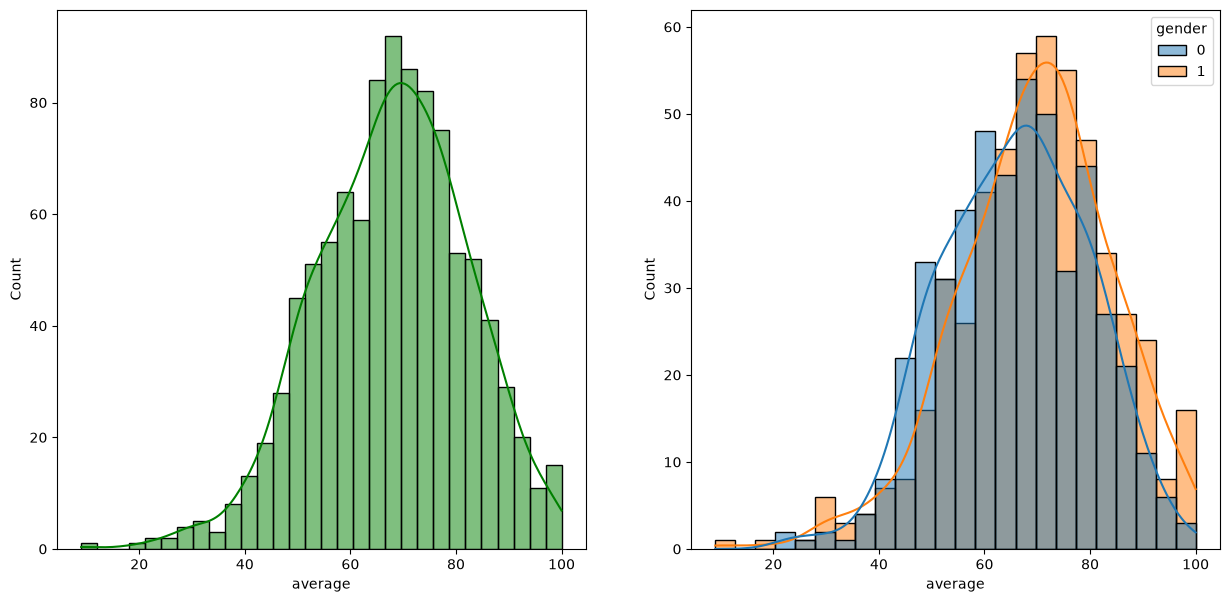

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

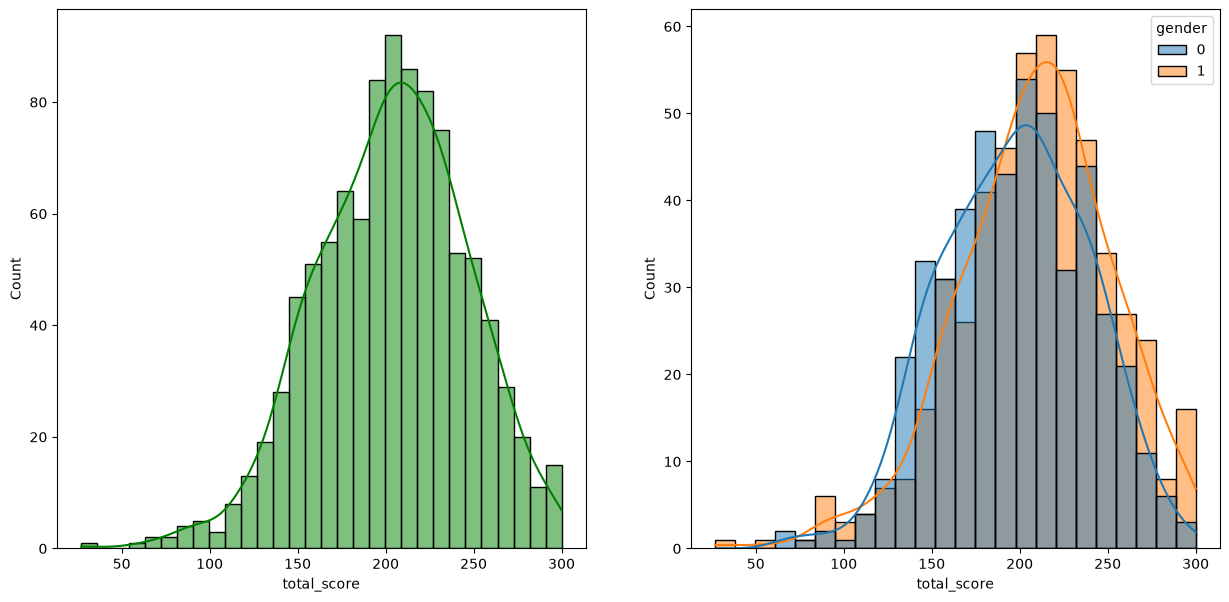

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.show()

**Insights**
* Female students tend to perform well then male students.

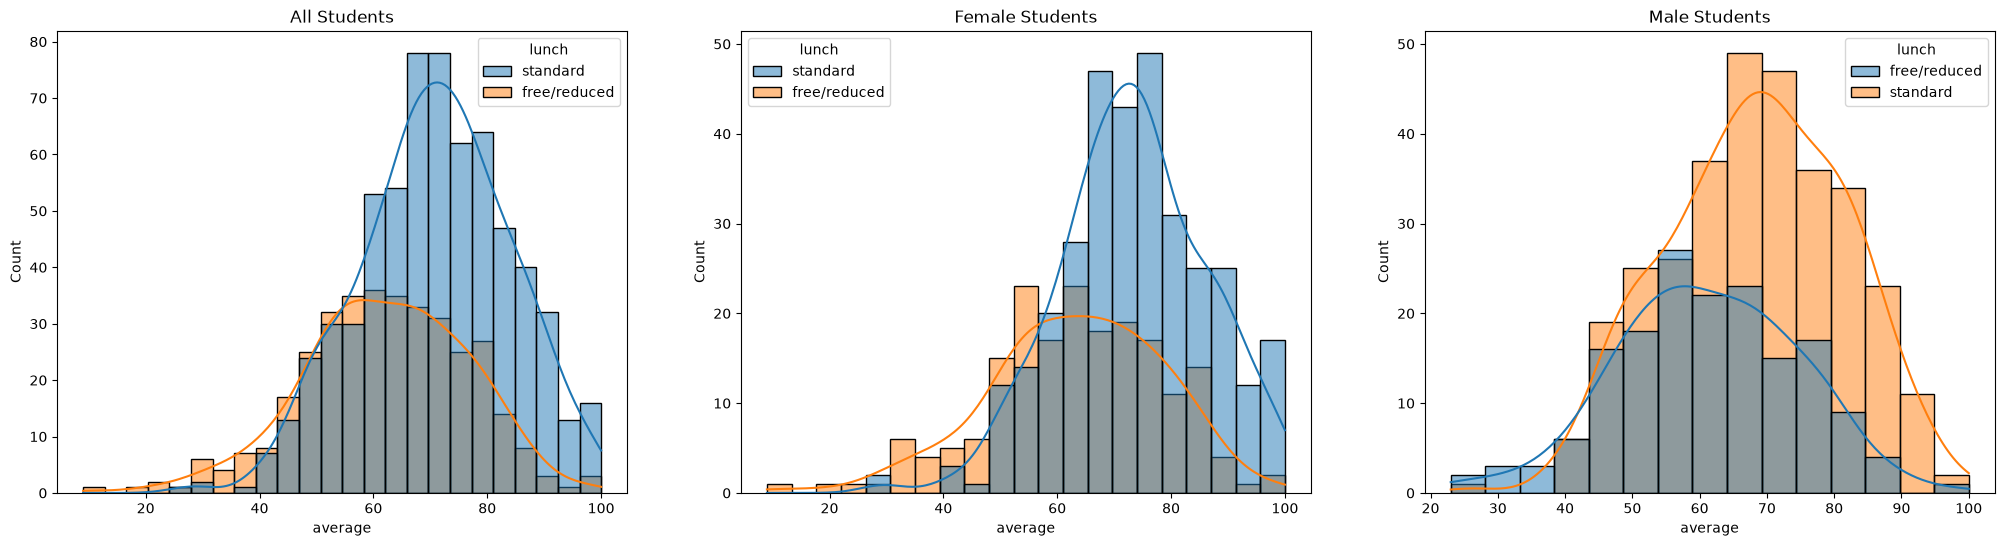

In [23]:
plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(1, 3, 1)
sns.histplot(data=df, x='average', kde=True, hue='lunch')
plt.title("All Students")

plt.subplot(1, 3, 2)
sns.histplot(data=df[df.gender == 1 ], x='average', kde=True, hue='lunch')
plt.title("Female Students")

plt.subplot(1, 3, 3)
sns.histplot(data=df[df.gender == 0 ], x='average', kde=True, hue='lunch')
plt.title("Male Students")

plt.show()


**Insights**
* Standard lunch helps perform well in exams.
* Standard lunch helps perform well in exams be it a male or a female.

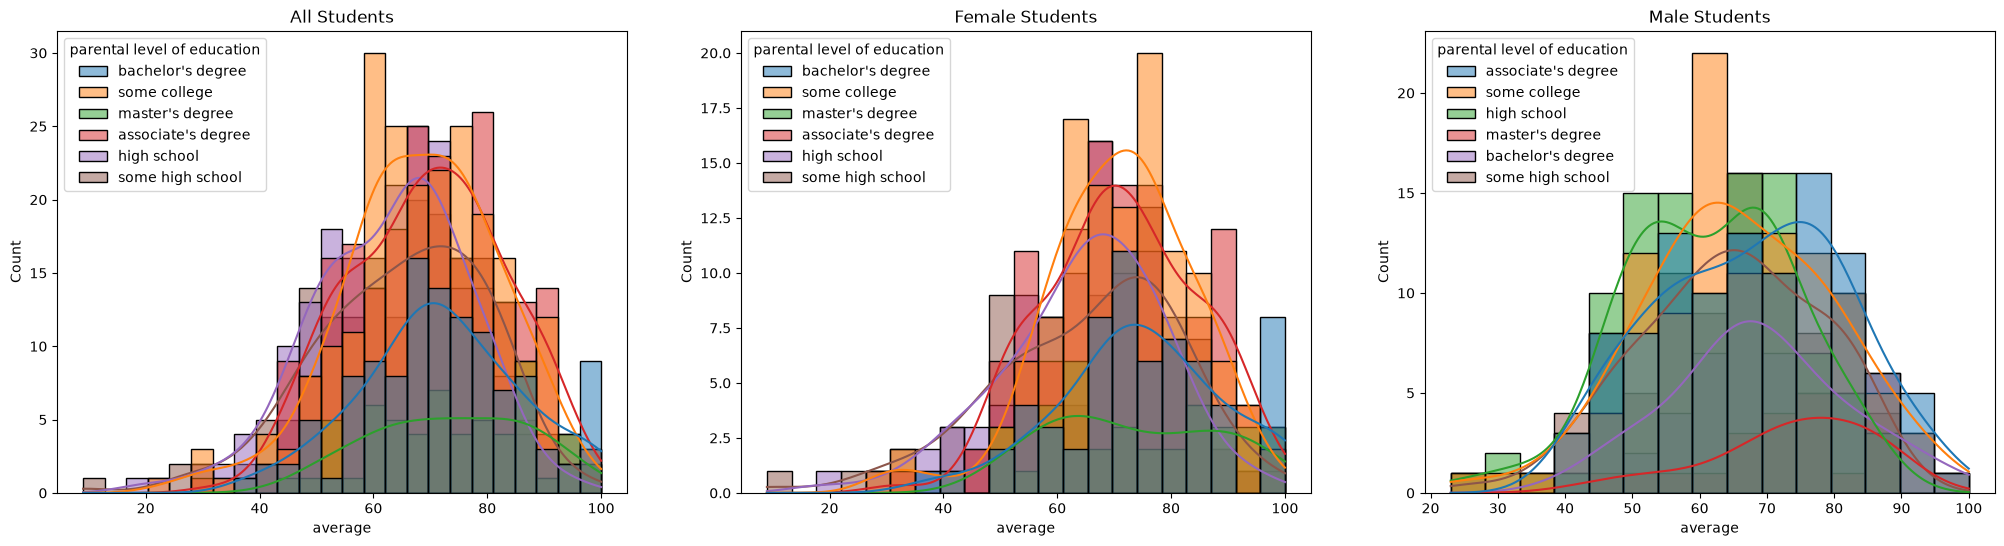

In [24]:
plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(1, 3, 1)
sns.histplot(data=df, x='average', kde=True, hue='parental level of education')
plt.title("All Students")

plt.subplot(1, 3, 2)
sns.histplot(data=df[df.gender == 1 ], x='average', kde=True, hue='parental level of education')
plt.title("Female Students")

plt.subplot(1, 3, 3)
sns.histplot(data=df[df.gender == 0 ], x='average', kde=True, hue='parental level of education')
plt.title("Male Students")

plt.show()


**Impact of Parental Education on Student Performance (Overall)**
* **Positive Correlation**: There is a direct positive relationship between parental education level and student average scores.
* **Higher Education** = **Higher Scores**: Students whose parents hold advanced degrees (master's degree or bachelor's degree) consistently achieve higher average scores, with KDE peaks shifted toward 75–85+.
* **Lower Education Tiers**: Students whose parents have high school or some high school education tend to cluster around lower-to-mid score ranges (50–65), representing a larger proportion of scores below 50.
**Gender-Specific Observations**
* Females show strong academic performance overall, with density concentrated in the 65–85 range.
* A significant number of female students whose parents have a bachelor's degree reach high scores near 90–100.
* The male score distribution is shifted slightly to the left compared to females, centering around 60–70.
* Males with parents holding an associate's degree or some college form a large proportion of the mid-tier score range (55–75).

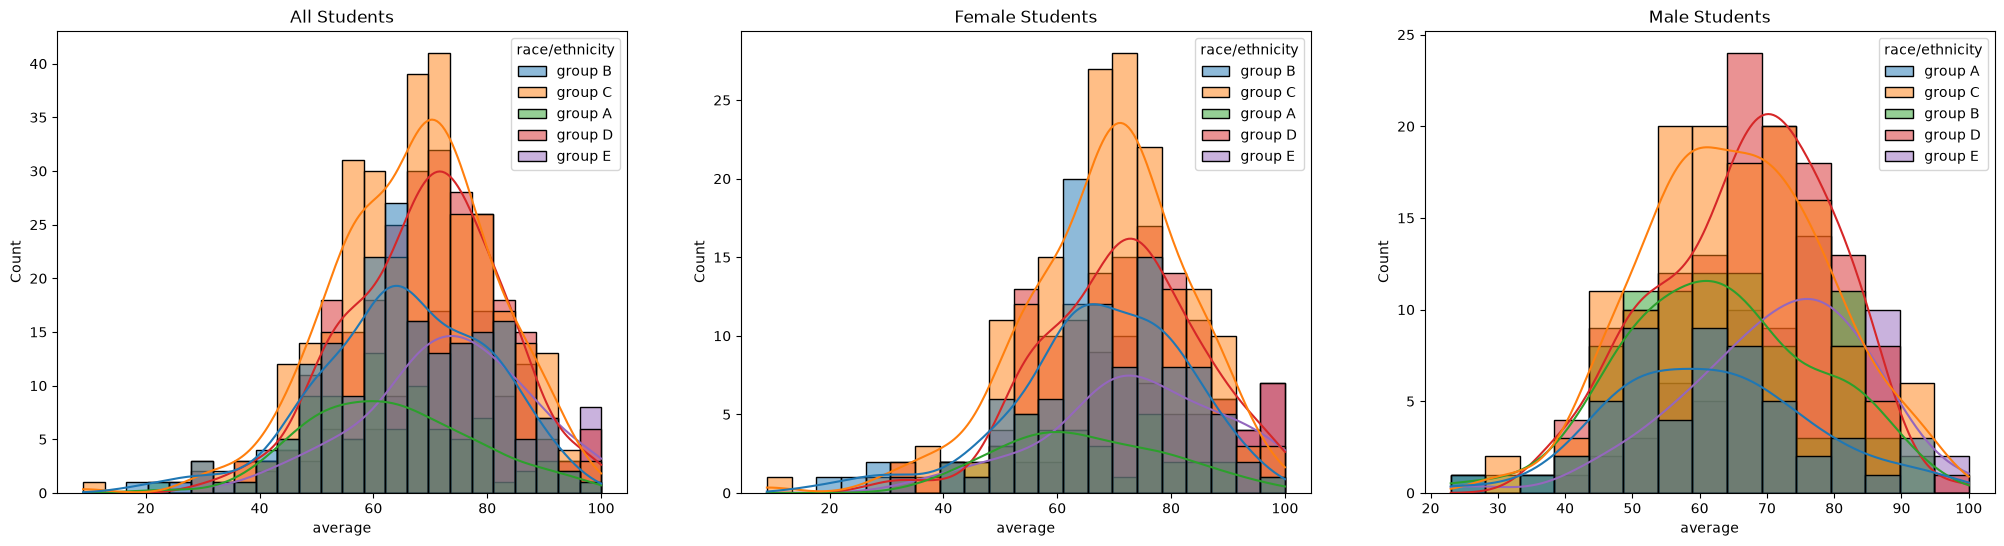

In [25]:
plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(1, 3, 1)
sns.histplot(data=df, x='average', kde=True, hue='race/ethnicity')
plt.title("All Students")

plt.subplot(1, 3, 2)
sns.histplot(data=df[df.gender == 1 ], x='average', kde=True, hue='race/ethnicity')
plt.title("Female Students")

plt.subplot(1, 3, 3)
sns.histplot(data=df[df.gender == 0 ], x='average', kde=True, hue='race/ethnicity')
plt.title("Male Students")

plt.show()


**Group Performance Rankings (Overall)**
* **Highest Performing Groups**: Group E (purple) and Group D (red) consistently achieve higher average scores. Their KDE distribution curves are shifted furthest to the right, peaking between 70 and 85+.
* **Moderate Performing Groups**: Group C (orange) and Group B (blue) represent the largest proportion of the student sample and are centered around the 60–70 average score range.
* **Lowest Performing Group**: Group A (green) has the smallest sample size and lower overall average scores, peaking around 55–65.
* Group C and Group D have the highest frequency (count) in the dataset, making up the bulk of the overall student population across all score ranges.
* Group A has the lowest representation among all race/ethnicity groups.
* Female performance is dominated by Group C and Group B in the 65–75 range.
* Group E and Group D females show strong representation at top score tiers (80–100).
* Group D males show a prominent spike around the 70–75 score mark.
* Group E males maintain higher scores overall, with minimal lower-tier representation.

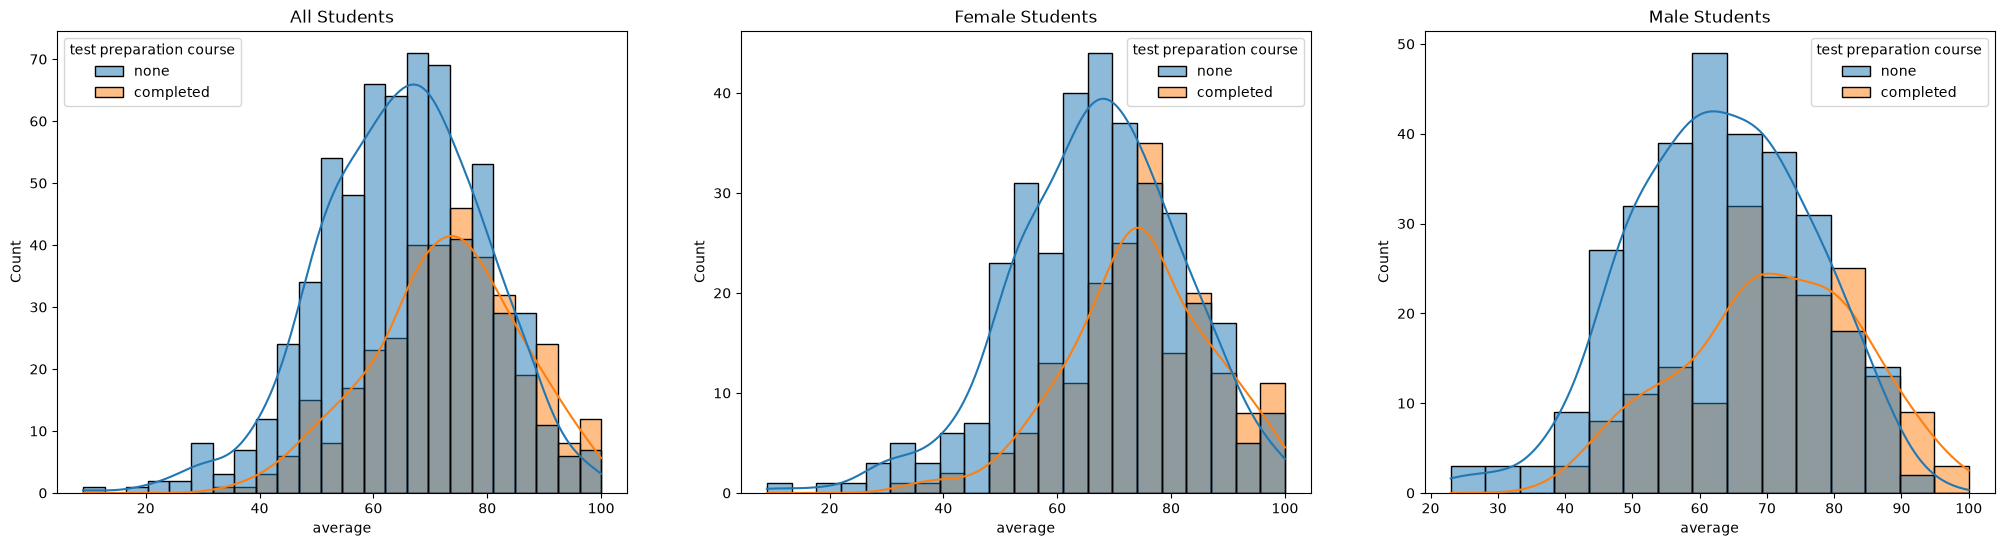

In [26]:
plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(1, 3, 1)
sns.histplot(data=df, x='average', kde=True, hue='test preparation course')
plt.title("All Students")

plt.subplot(1, 3, 2)
sns.histplot(data=df[df.gender == 1 ], x='average', kde=True, hue='test preparation course')
plt.title("Female Students")

plt.subplot(1, 3, 3)
sns.histplot(data=df[df.gender == 0 ], x='average', kde=True, hue='test preparation course')
plt.title("Male Students")

plt.show()


**Insights**
* Score Shift to the Right: Students who completed the test preparation course (orange) consistently achieve higher average scores. Their distribution curve is noticeably shifted to the right, peaking around 72–78.
* Lower Performance Without Course: Students who did not complete the course (none - blue) have a lower median score, peaking around 62–68, and represent nearly all of the low scores below 40.
* Elimination of Low Performers: Completing the test prep course acts as an effective safety net—almost zero students who completed the course scored below 40.
* A majority of students in the dataset did not complete the test preparation course (none has a significantly higher overall count than completed).
* Females who completed the test prep course show a strong, sharp peak near 74–78, with a notable portion achieving top-tier scores (80–100).
* Females without the course peak around 65–70.
* Males who completed the test prep course shift from a peak of ~60 (for none) up to 70–76 (for completed).


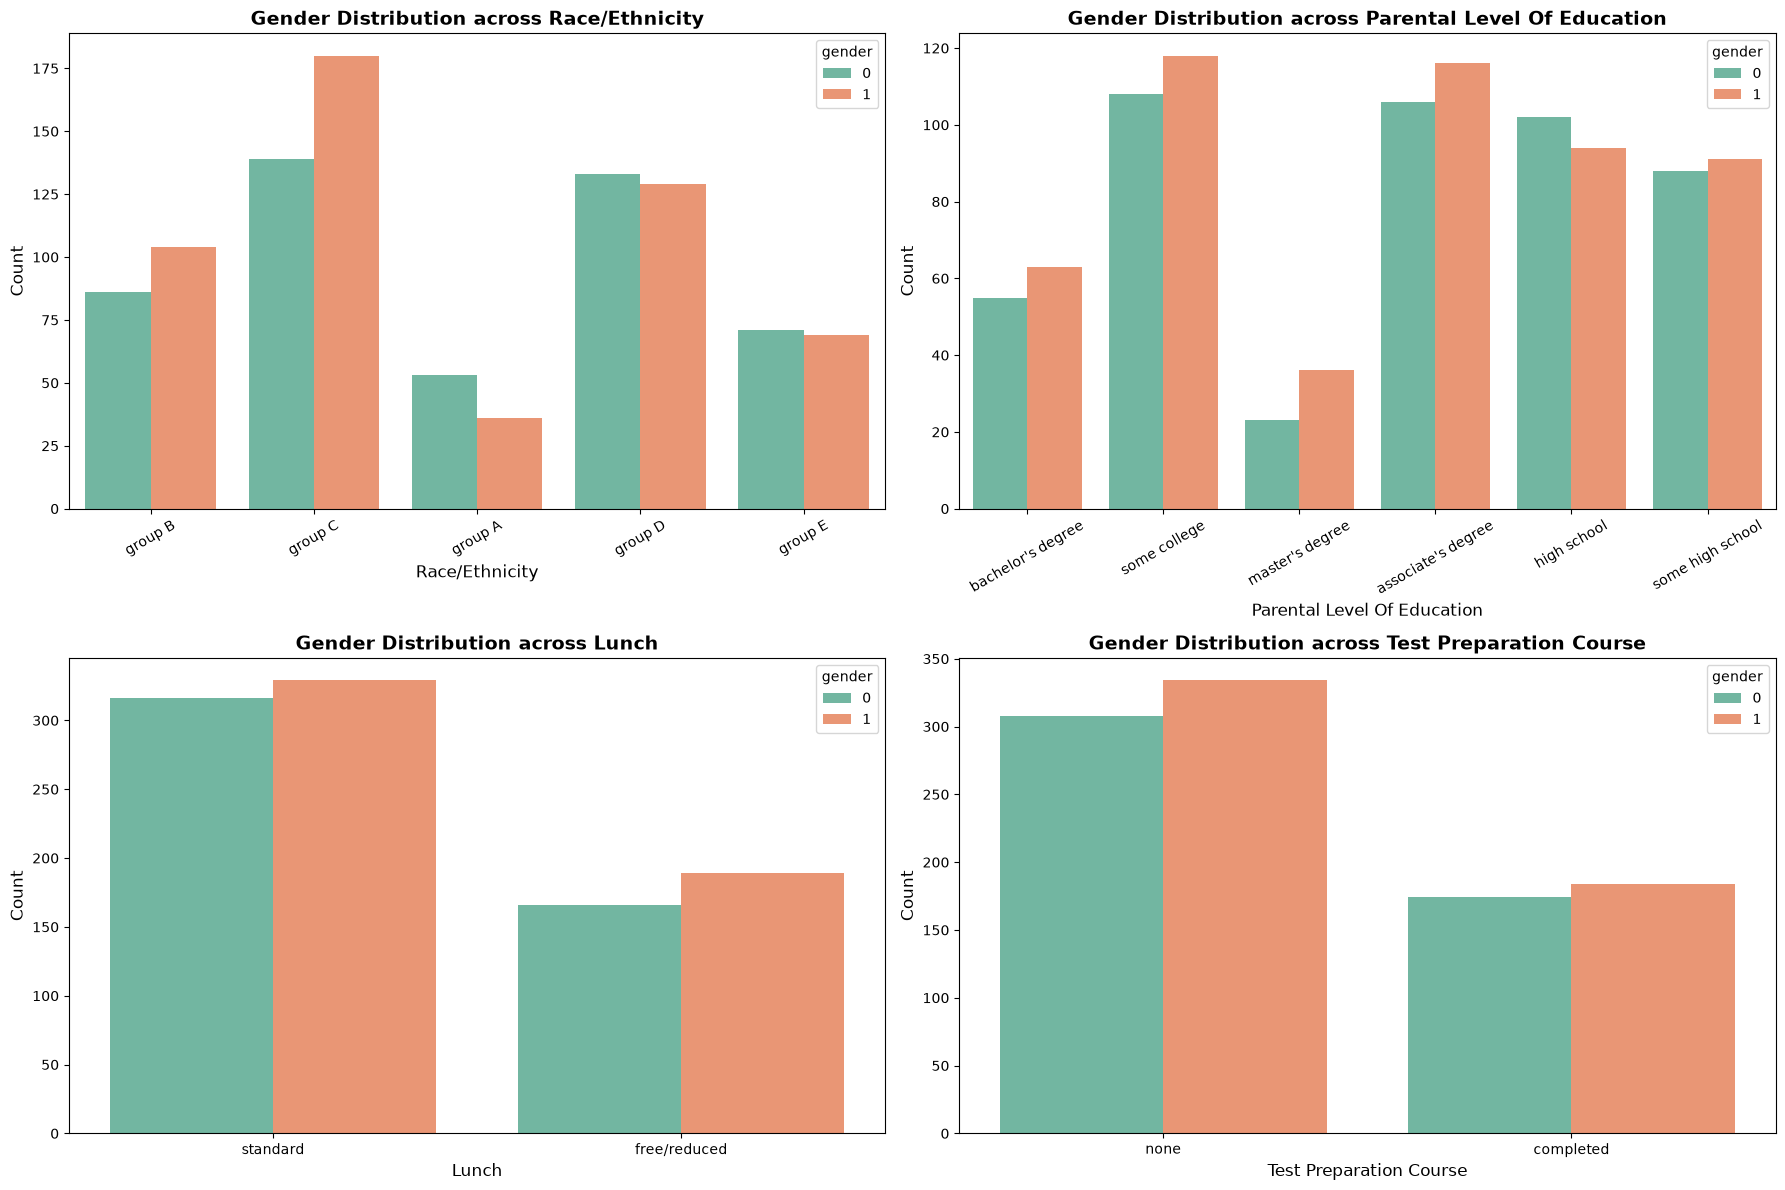

In [27]:
# Select categorical attributes (excluding gender itself)
categorical_features = ['race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, hue='gender', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Gender Distribution across {col.title()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col.title(), fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    
    # Rotate x-axis labels for readability if long text
    if len(df[col].unique()) > 3:
        axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Balanced Distribution: Gender is fairly evenly distributed across all socio-demographic categories (Lunch, Test Prep, Parental Education, and Race/Ethnicity). This confirms no major gender sampling bias in the dataset.**

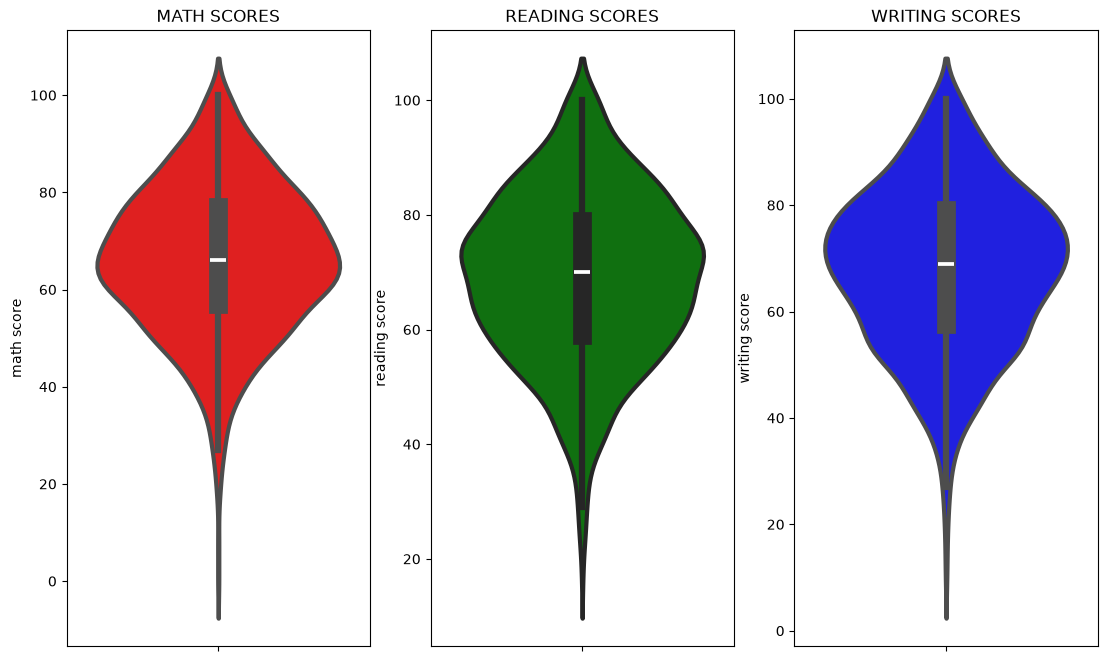

In [28]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score',data=df,color='blue',linewidth=3)
plt.show()

**Insights**
* From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

#### **4.2 Multivariate analysis using pieplot**

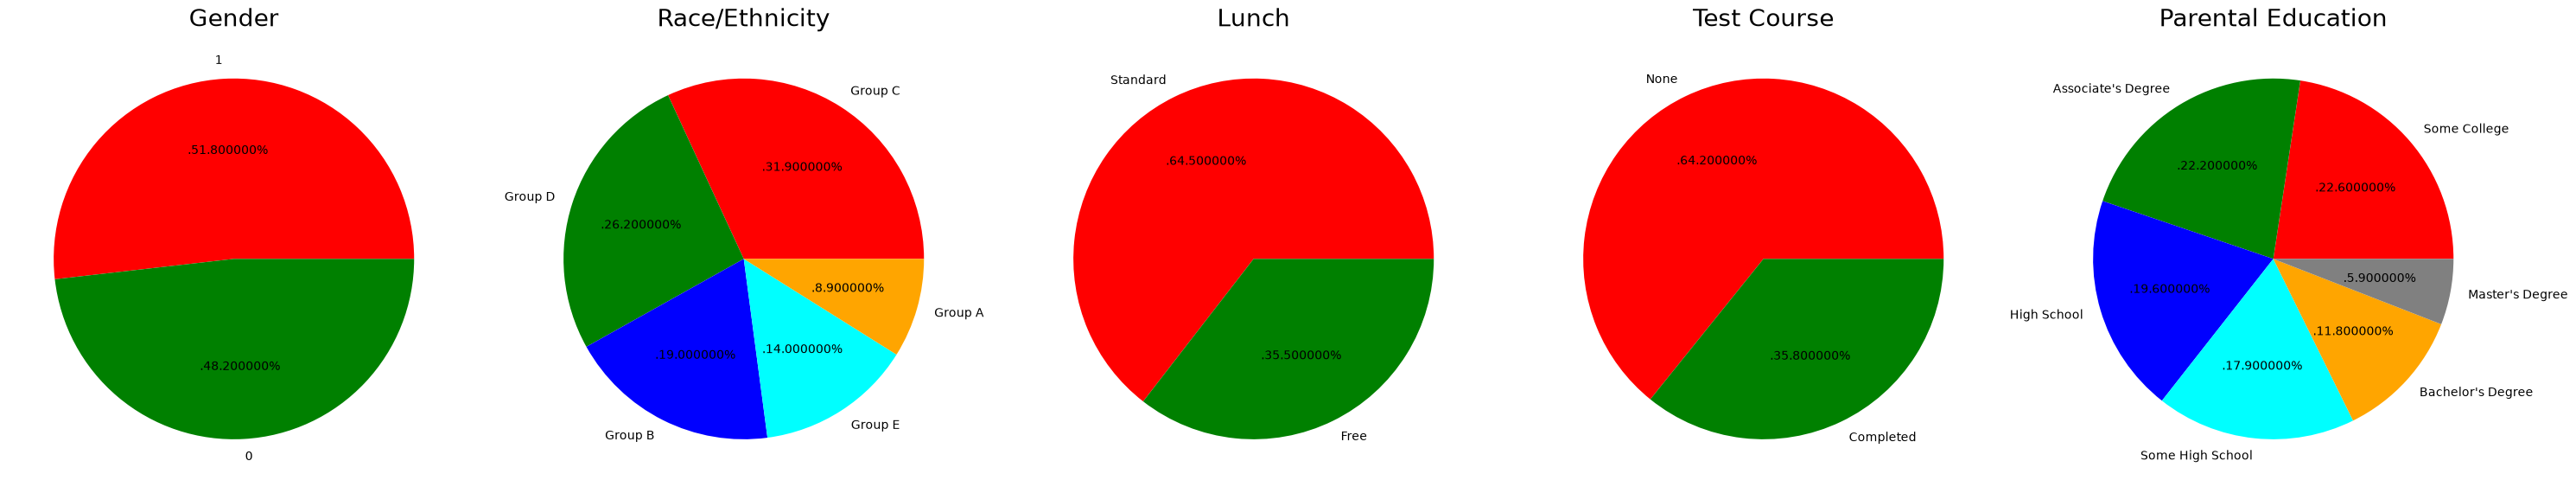

In [29]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 1, 0
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

**Insights**
* Number of Male and Female students is almost equal
* Number students are greatest in Group C
* Number of students who have standard lunch are greater
* Number of students who have not enrolled in any test preparation course is greater
* Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

#### **4.3 Feature Wise Visualization**

##### **4.3.1 Gender**
UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

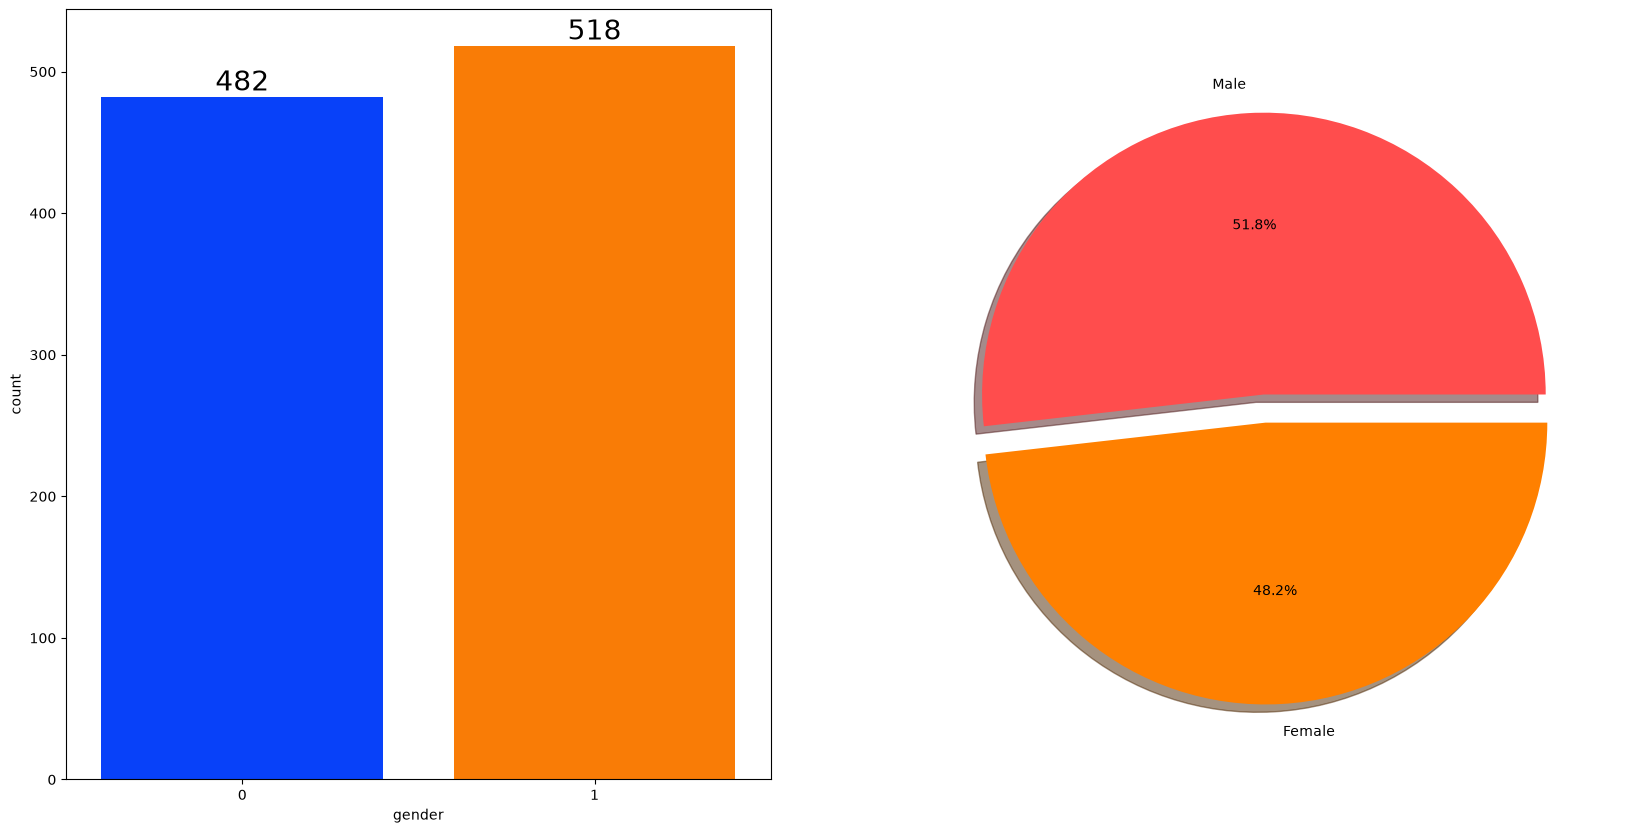

In [30]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

**Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)**

**BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )**

In [31]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math score,reading score,writing score,total_score,average
gender,,,,,
0,68.728216,65.473029,63.311203,197.512448,65.837483
1,63.633205,72.608108,72.467181,208.708494,69.569498


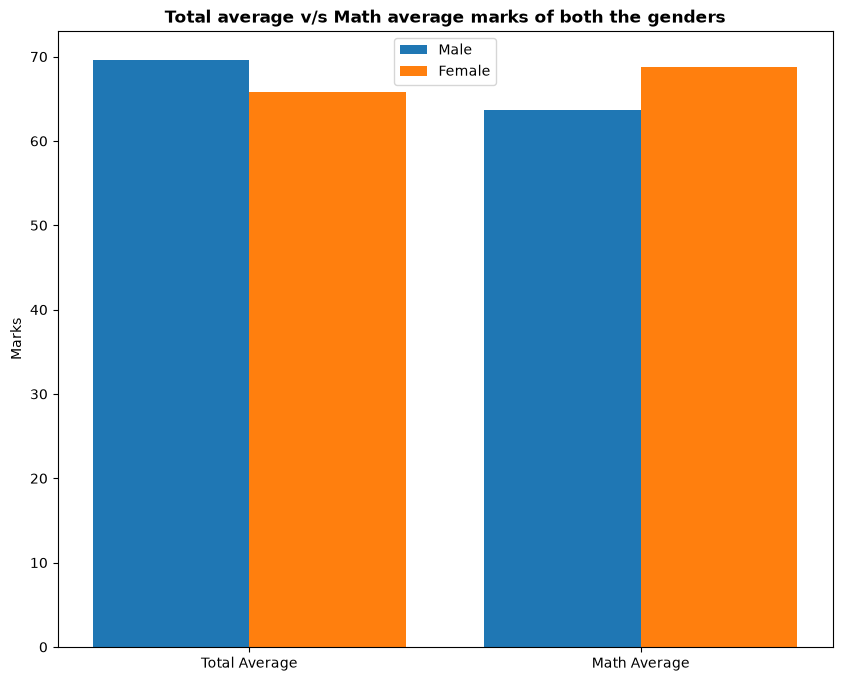

In [32]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['average'][0], gender_group['math score'][0]]
male_scores = [gender_group['average'][1], gender_group['math score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

**Insights**
* On an average males have a better overall score than female.
* whereas females have scored higher in Maths.

##### **4.3.2 RACE/EHNICITY COLUMN**
UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

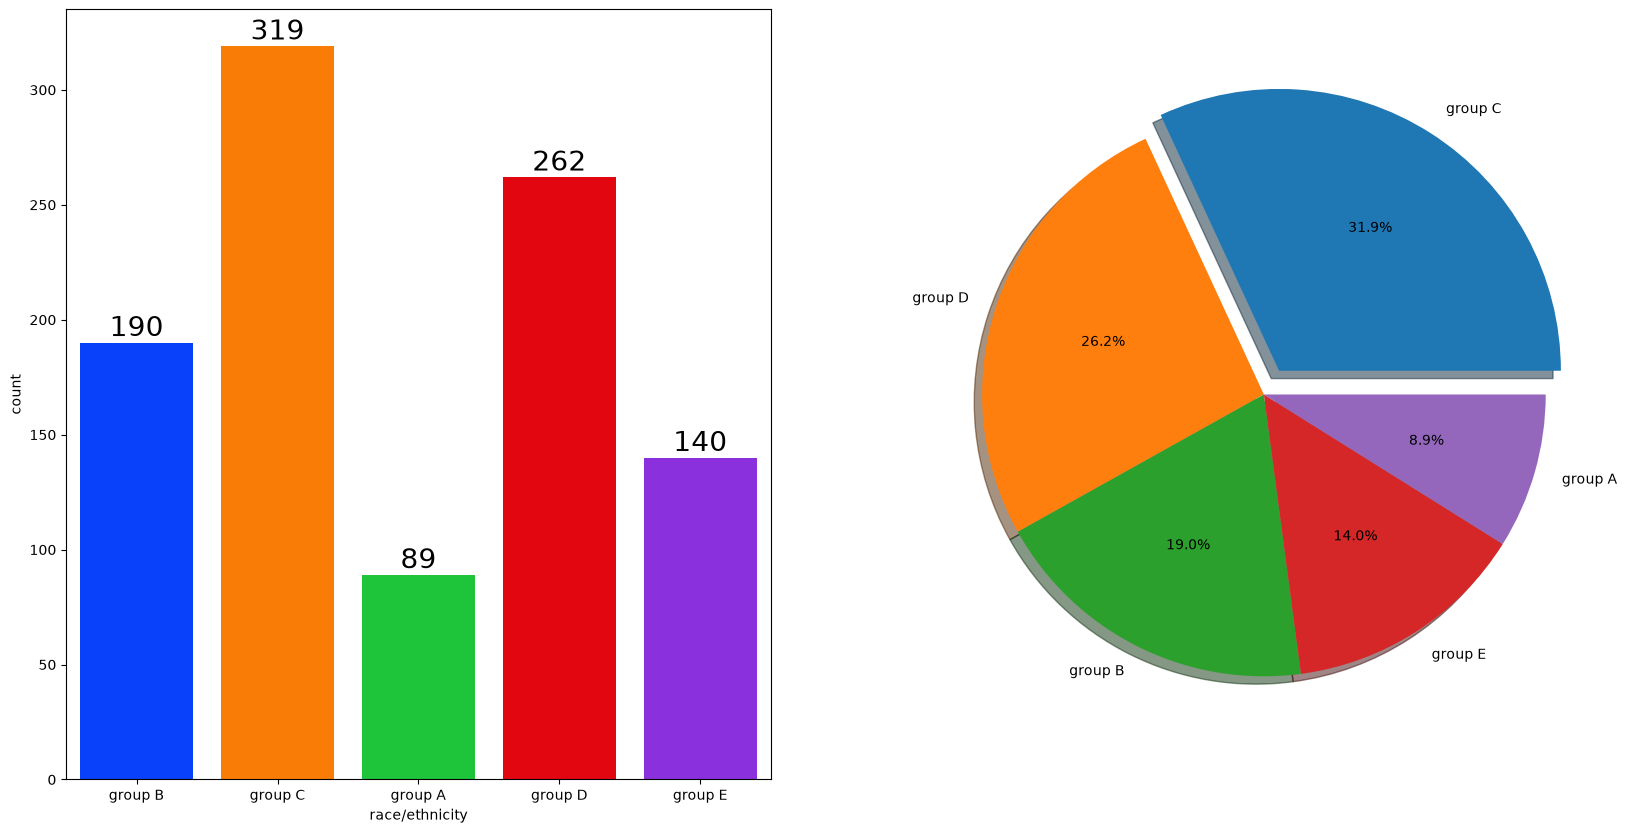

In [33]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race/ethnicity'].value_counts(),labels=df['race/ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()  

**Insights**
* Group C and Group D together makes up 58% of total students. 
* Group A has only 9% representation. 

BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

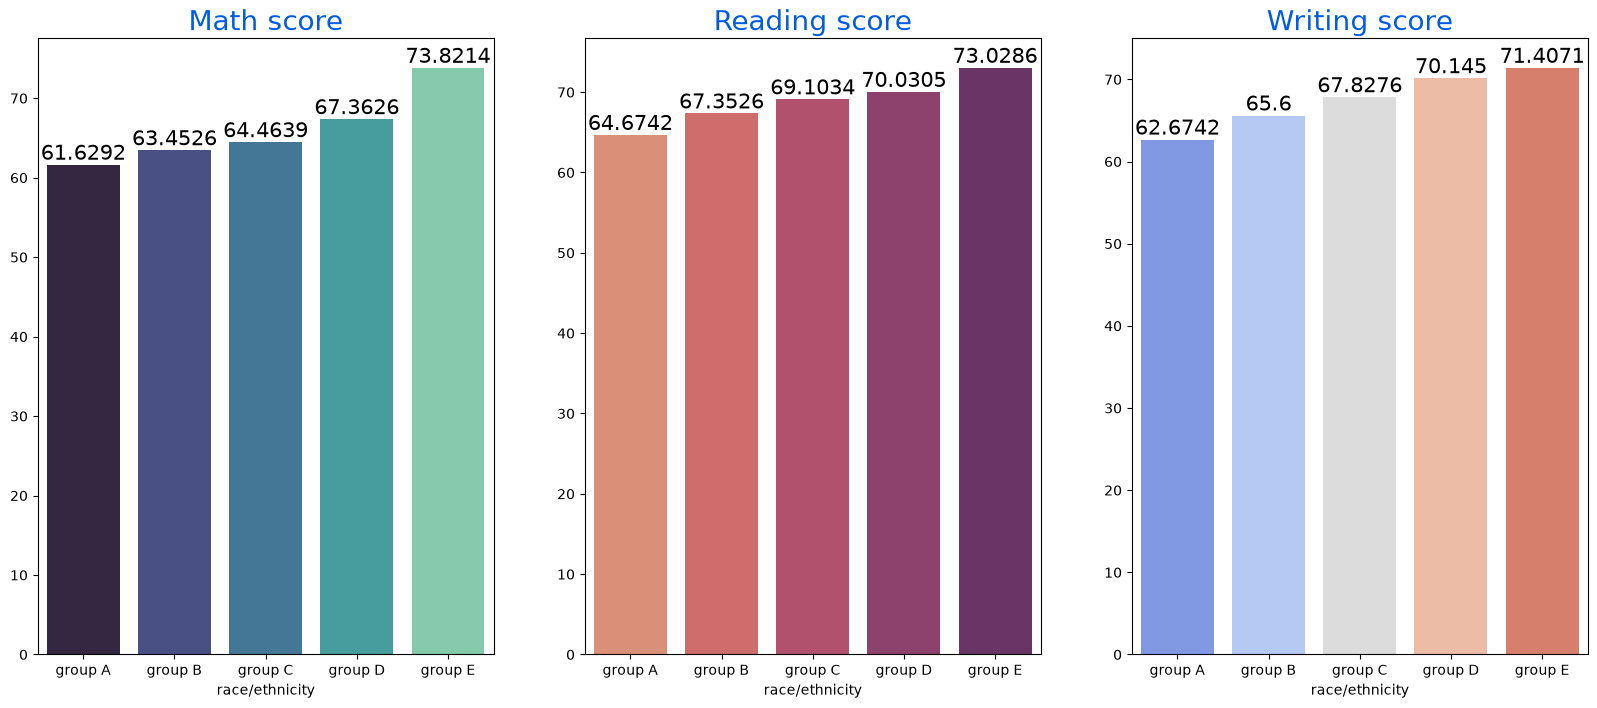

In [34]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

**Insights**
* Group E with only 14% representation, has scored the highest in all the subjects. 
* Group A has the lowest score across all subjects. We can infer Group A students have a lower socio-economic condition.
* We can observe similar pattern in all the subjects for all the ethnicities. 

##### **4.3.2 Parental Level of Education**
UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

findfont: Failed to find font weight 30, now using 400.


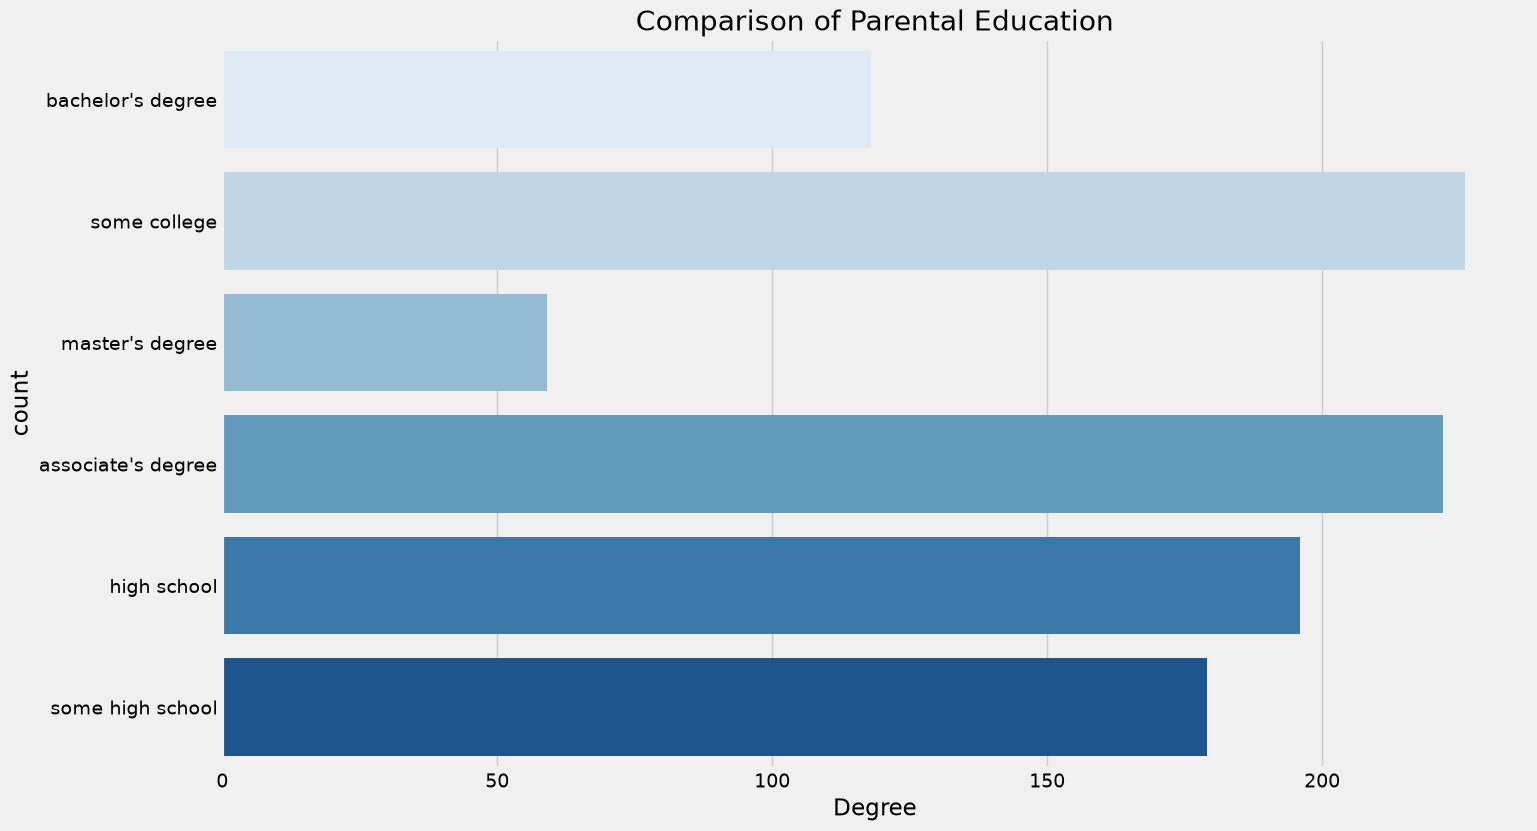

In [35]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

In [36]:
parents_group = df.groupby('parental level of education').mean(numeric_only=True)
parents_group

,gender,math score,reading score,writing score,total_score,average
parental level of education,,,,,,
associate's degree,0.522523,67.882883,70.927928,69.896396,208.707207,69.569069
bachelor's degree,0.533898,69.389831,73.000000,73.381356,215.771186,71.923729
high school,0.479592,62.137755,64.704082,62.448980,189.290816,63.096939
master's degree,0.610169,69.745763,75.372881,75.677966,220.796610,73.598870
some college,0.522124,67.128319,69.460177,68.840708,205.429204,68.476401
some high school,0.508380,63.497207,66.938547,64.888268,195.324022,65.108007


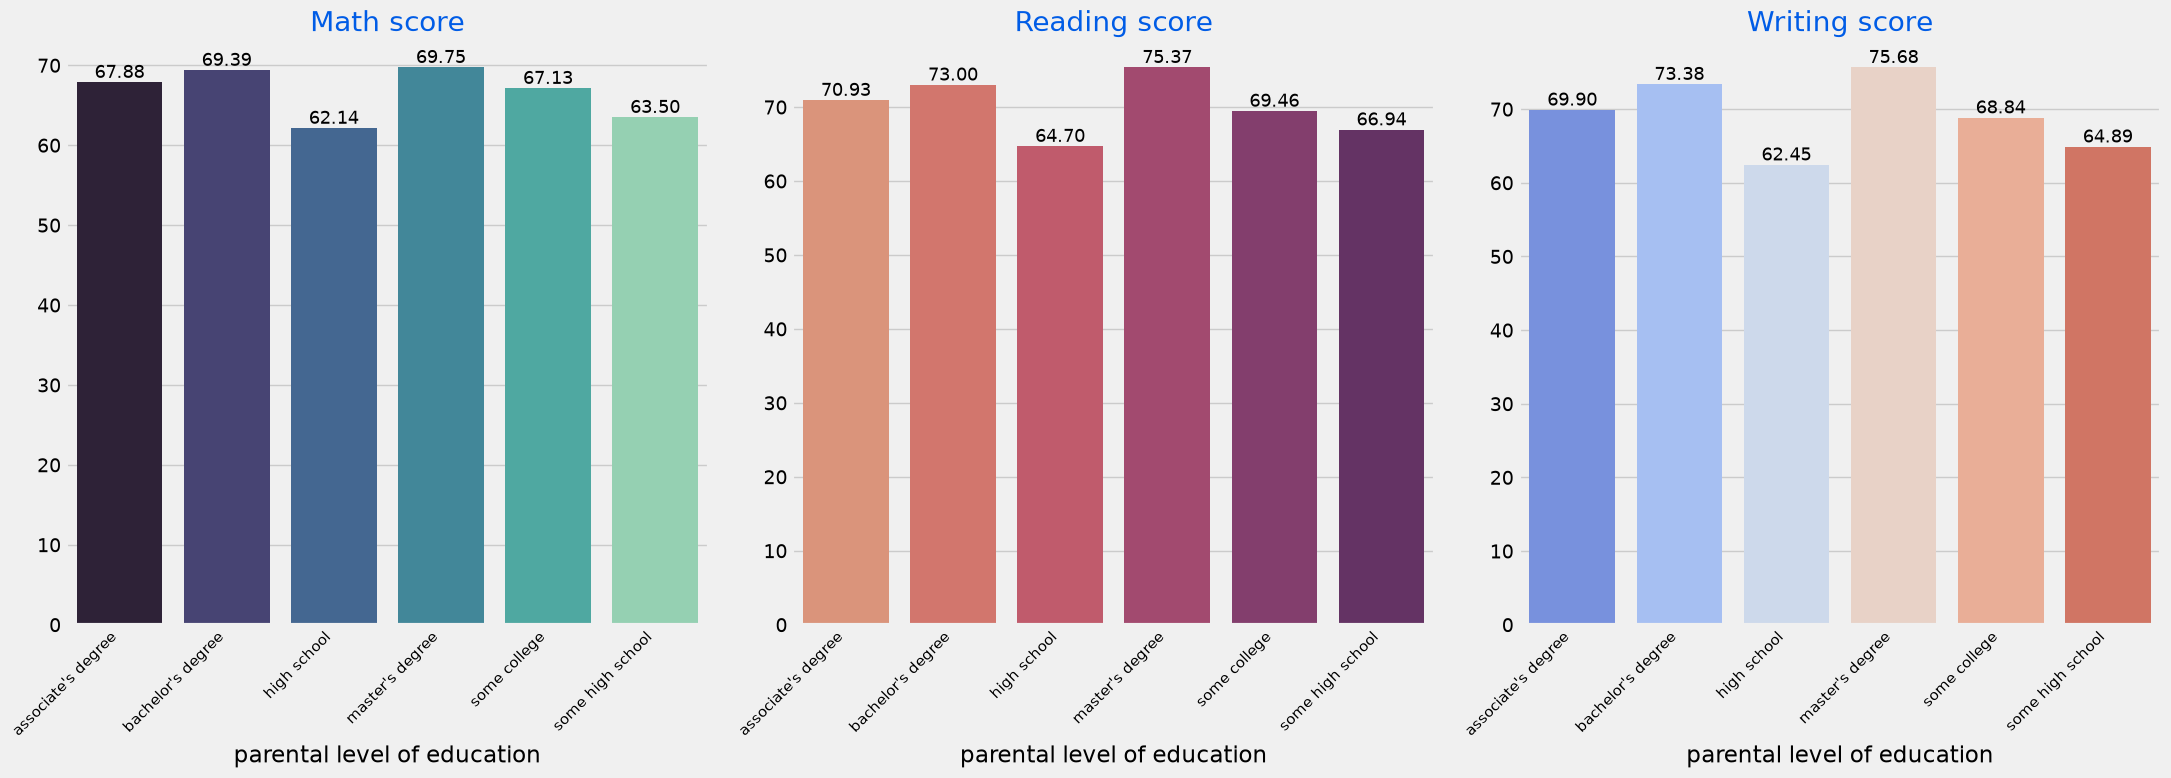

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

Group_data2 = df.groupby('parental level of education')

f, ax = plt.subplots(1, 3, figsize=(22, 8))

# 1. Math Score Bar Plot
sns.barplot(x=Group_data2['math score'].mean().index, y=Group_data2['math score'].mean().values, palette='mako', ax=ax[0])
ax[0].set_title('Math score', color='#005ce6', size=20)
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right', fontsize=11)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.2f', color='black', size=13)

# 2. Reading Score Bar Plot
sns.barplot(x=Group_data2['reading score'].mean().index, y=Group_data2['reading score'].mean().values, palette='flare', ax=ax[1])
ax[1].set_title('Reading score', color='#005ce6', size=20)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right', fontsize=11)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.2f', color='black', size=13)

# 3. Writing Score Bar Plot
sns.barplot(x=Group_data2['writing score'].mean().index, y=Group_data2['writing score'].mean().values, palette='coolwarm', ax=ax[2])
ax[2].set_title('Writing score', color='#005ce6', size=20)
ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation=45, ha='right', fontsize=11)
for container in ax[2].containers:
    ax[2].bar_label(container, fmt='%.2f', color='black', size=13)

plt.tight_layout()
plt.show()


**Insights**
* The score of student whose parents possess master and bachelor level education are higher than others.
* The scor eof students with parents possess high school has the lowest score. 
* The parental education is directly corelated with the student's score. 

##### **4.3.3 Lunch**

UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

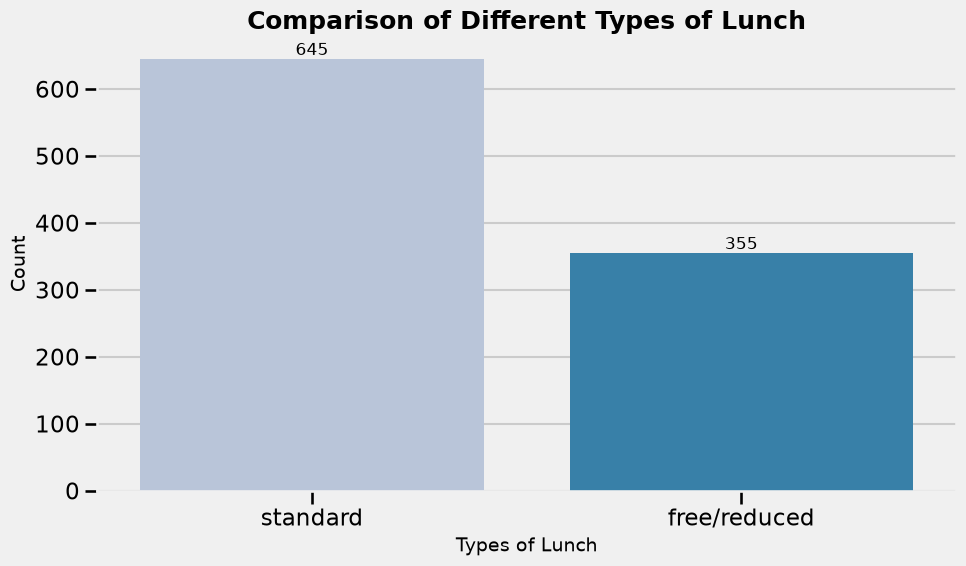

In [38]:
# Set figure size and seaborn context
plt.figure(figsize=(10, 6))
sns.set_context('talk')  # Fixed: replaces deprecated plt.style.use('seaborn-talk')
# Fixed: Use keyword arguments (data=df, x='lunch') and hue for palette
ax = sns.countplot(data=df, x='lunch', palette='PuBu', hue='lunch', legend=False)
# Fixed: Changed fontweight=30 to fontweight='bold'
plt.title('Comparison of Different Types of Lunch', fontweight='bold', fontsize=18)
plt.xlabel('Types of Lunch', fontsize=14)
plt.ylabel('Count', fontsize=14)
# Optional: Add count labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fontsize=12)
plt.tight_layout()
plt.show()

**Number of students having standard lunch is more than the free/reduced type of lunch.**

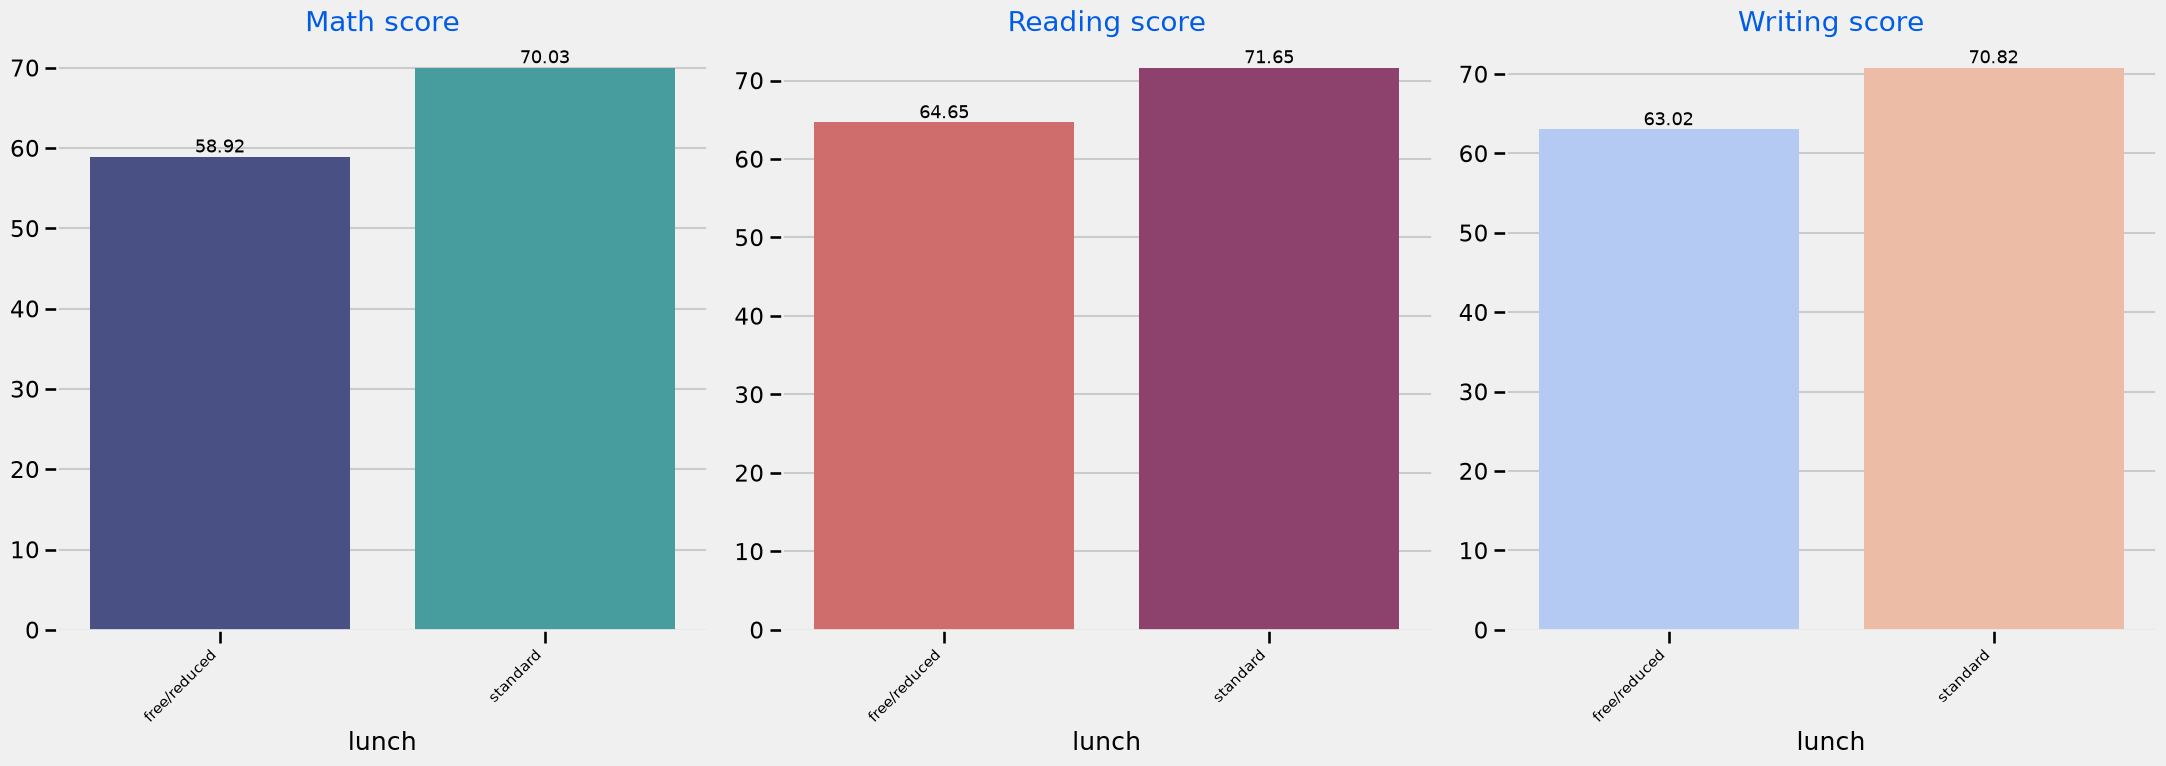

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

Group_data2 = df.groupby('lunch')

f, ax = plt.subplots(1, 3, figsize=(22, 8))

# 1. Math Score Bar Plot
sns.barplot(x=Group_data2['math score'].mean().index, y=Group_data2['math score'].mean().values, palette='mako', ax=ax[0])
ax[0].set_title('Math score', color='#005ce6', size=20)
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right', fontsize=11)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.2f', color='black', size=13)

# 2. Reading Score Bar Plot
sns.barplot(x=Group_data2['reading score'].mean().index, y=Group_data2['reading score'].mean().values, palette='flare', ax=ax[1])
ax[1].set_title('Reading score', color='#005ce6', size=20)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right', fontsize=11)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.2f', color='black', size=13)

# 3. Writing Score Bar Plot
sns.barplot(x=Group_data2['writing score'].mean().index, y=Group_data2['writing score'].mean().values, palette='coolwarm', ax=ax[2])
ax[2].set_title('Writing score', color='#005ce6', size=20)
ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation=45, ha='right', fontsize=11)
for container in ax[2].containers:
    ax[2].bar_label(container, fmt='%.2f', color='black', size=13)

plt.tight_layout()
plt.show()


**Students perform better who have the standard lunch in all the subjects**

##### **4.4.4 Test Preparation Course**

UNIVARIATE ANALYSIS ( Which type of test preparation course is most common amoung students ? )

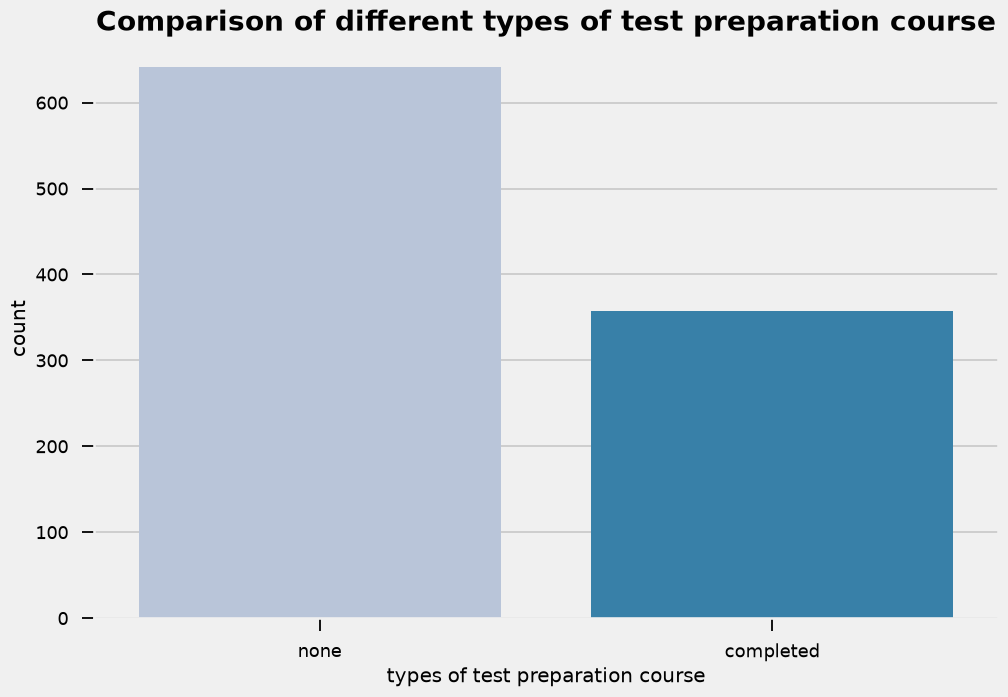

In [40]:
# 1. Figure size configuration
plt.rcParams["figure.figsize"] = (15, 9)

# 2. Matplotlib style configuration
plt.style.use("seaborn-v0_8-talk")

# 3. Seaborn plot syntax + corrected column name spelling ('preparation' instead of 'preperation')
sns.countplot(
    data=df,
    x="test preparation course",
    hue="test preparation course",
    palette="PuBu",
    legend=False,
)

# 4. Title and label formatting
plt.title(
    "Comparison of different types of test preparation course",
    fontweight="bold",
    fontsize=20,
)
plt.xlabel("types of test preparation course")
plt.ylabel("count")

plt.show()

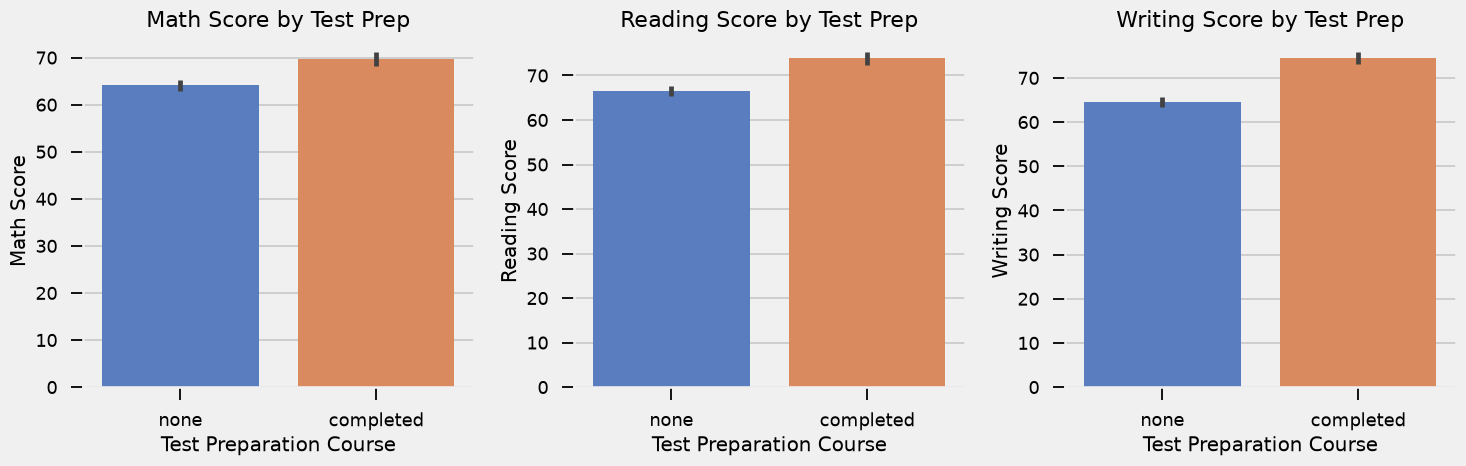

In [41]:
# Set figure size for the subplots
plt.figure(figsize=(15, 5))

# 1. Math Score vs Test Preparation Course
plt.subplot(1, 3, 1)
sns.barplot(
    data=df,
    x="test preparation course",
    y="math score",
    palette="muted",
    hue="test preparation course",
    legend=False,
)
plt.title("Math Score by Test Prep")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")

# 2. Reading Score vs Test Preparation Course
plt.subplot(1, 3, 2)
sns.barplot(
    data=df,
    x="test preparation course",
    y="reading score",
    palette="muted",
    hue="test preparation course",
    legend=False,
)
plt.title("Reading Score by Test Prep")
plt.xlabel("Test Preparation Course")
plt.ylabel("Reading Score")

# 3. Writing Score vs Test Preparation Course
plt.subplot(1, 3, 3)
sns.barplot(
    data=df,
    x="test preparation course",
    y="writing score",
    palette="muted",
    hue="test preparation course",
    legend=False,
)
plt.title("Writing Score by Test Prep")
plt.xlabel("Test Preparation Course")
plt.ylabel("Writing Score")

# Adjust layout for clear presentation
plt.tight_layout()
plt.show()

**The students with completed test prepration course has scored better in all the subjects.**

##### **4.4.5 Checking Outliers**

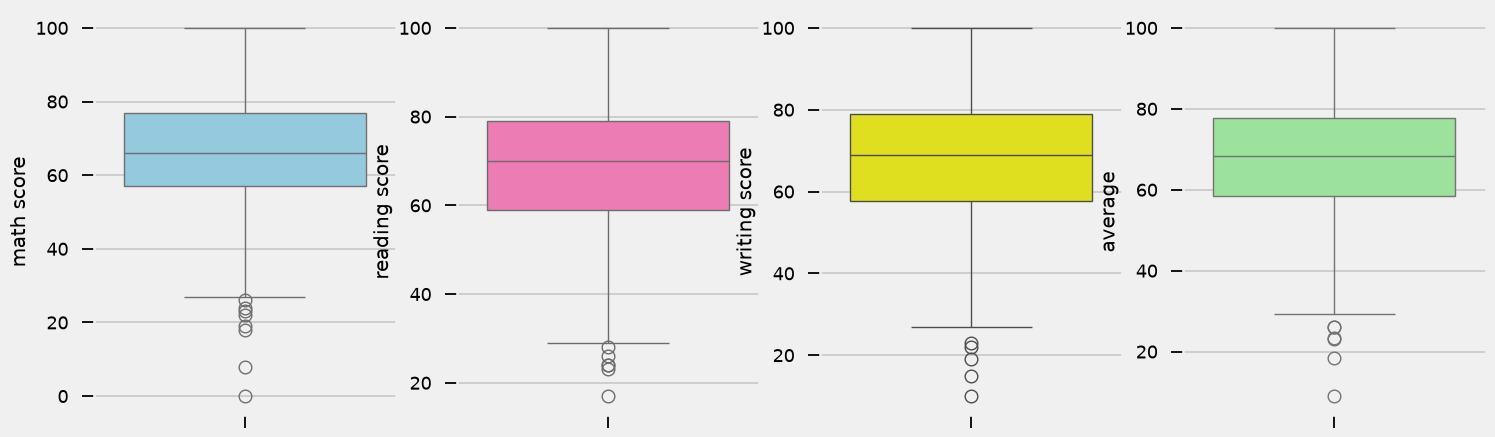

In [42]:

plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

##### **4.4.6 MUTIVARIATE ANALYSIS USING PAIRPLOT**

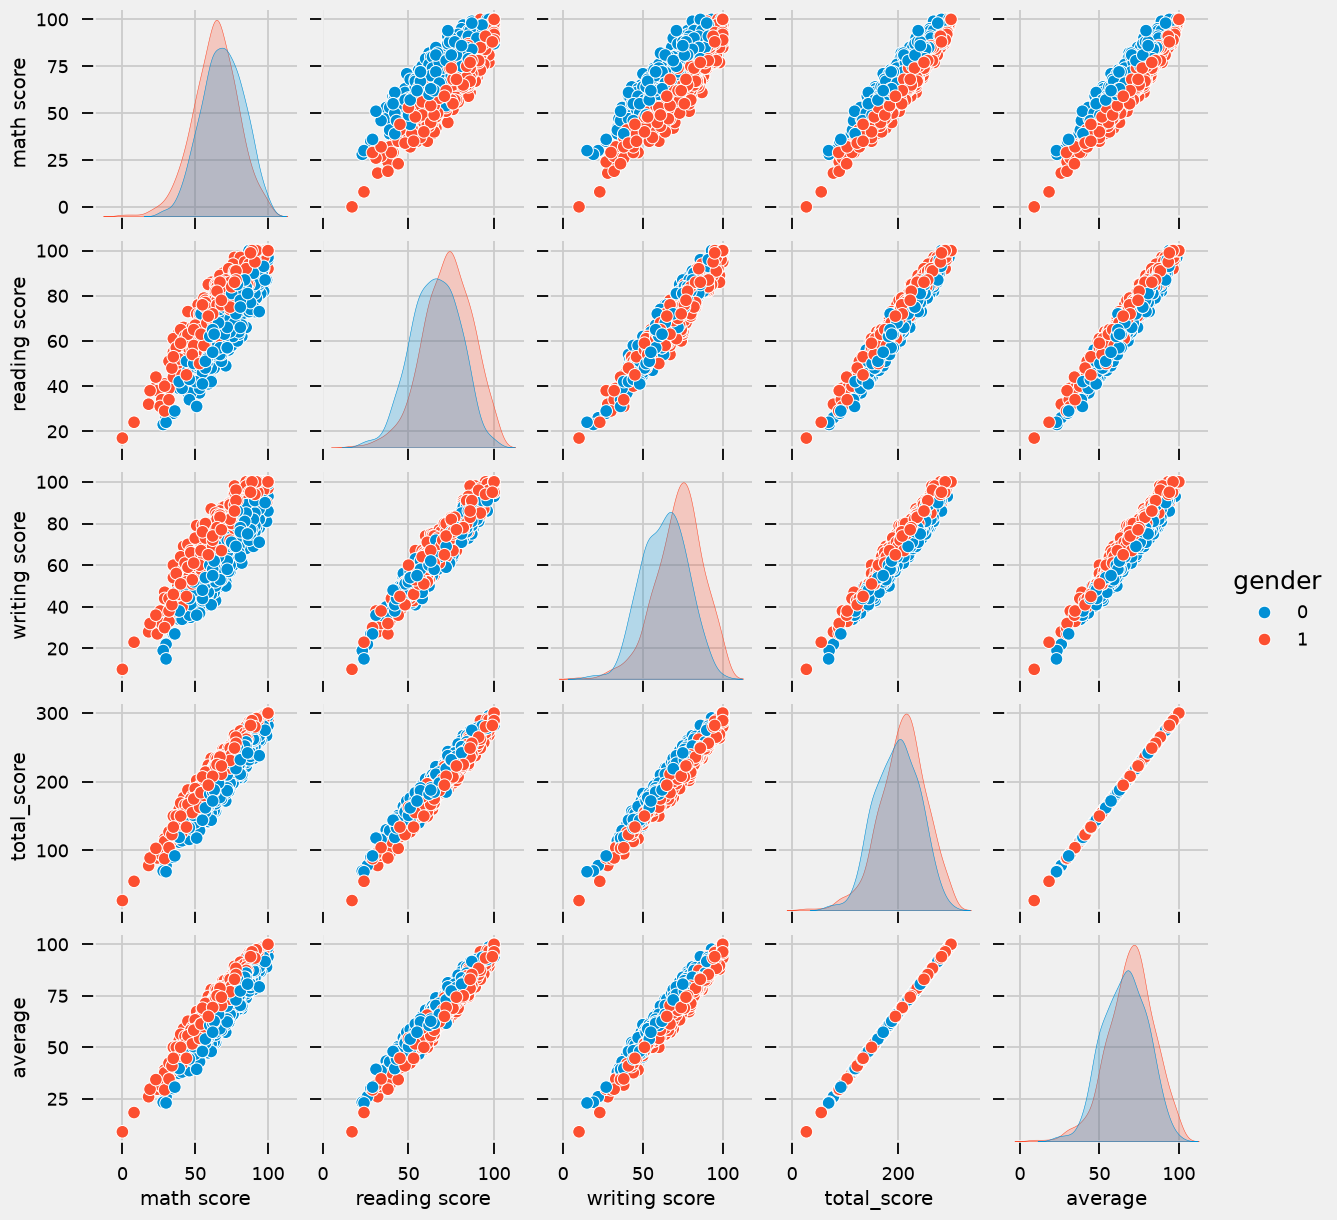

In [43]:
sns.pairplot(df,hue = 'gender')
plt.show()

**From the above plot it is clear that all the scores increase linearly with each other.**

* Student's Performance is related with lunch, race, parental level education
* Females lead in pass percentage and also are top-scorers
* Student's Performance is not much related with test preparation course
* Finishing preparation course is benefitial.